Libraries loaded
Status code 200
Books found: 20
                                   title    price rating
0                   A Light in the Attic  Â£51.77  Three
1                     Tipping the Velvet  Â£53.74    One
2                             Soumission  Â£50.10    One
3                          Sharp Objects  Â£47.82   Four
4  Sapiens: A Brief History of Humankind  Â£54.23   Five
                                   title  price rating
0                   A Light in the Attic  51.77  Three
1                     Tipping the Velvet  53.74    One
2                             Soumission  50.10    One
3                          Sharp Objects  47.82   Four
4  Sapiens: A Brief History of Humankind  54.23   Five
                                   title  price rating  rating_num
0                   A Light in the Attic  51.77  Three           3
1                     Tipping the Velvet  53.74    One           1
2                             Soumission  50.10    One           1
3          

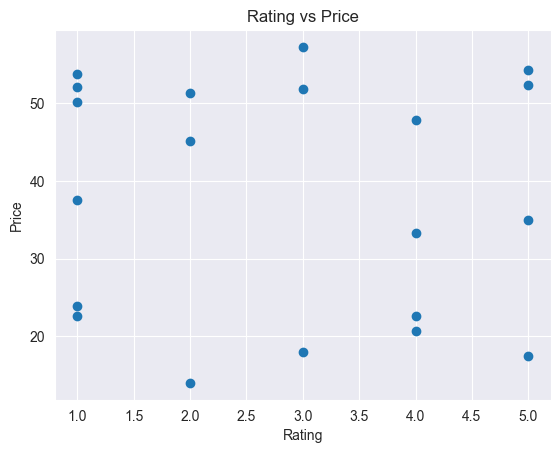

                                                title    price rating
0                                A Light in the Attic  Â£51.77  Three
1                                  Tipping the Velvet  Â£53.74    One
2                                          Soumission  Â£50.10    One
3                                       Sharp Objects  Â£47.82   Four
4               Sapiens: A Brief History of Humankind  Â£54.23   Five
..                                                ...      ...    ...
95  Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...  Â£19.92    Two
96  Layered: Baking, Building, and Styling Spectac...  Â£40.11    One
97  Judo: Seven Steps to Black Belt (an Introducto...  Â£53.90    Two
98                                               Join  Â£35.67   Five
99          In the Country We Love: My Family Divided  Â£22.00   Four

[100 rows x 3 columns]
                                   title  price rating  rating_num
0                   A Light in the Attic  51.77  Three           3
1 

In [21]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded")

url = "http://books.toscrape.com/"
response = requests.get(url)
print(f"Status code {response.status_code}")

soup = BeautifulSoup(response.text, "html.parser")
books = soup.find_all("article", class_="product_pod")
print(f"Books found: {len(books)}")

book_list = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.p["class"][1]

    book_list.append({
        "title": title,
        "price": price,
        "rating": rating
    })

df = pd.DataFrame(book_list)
print(df.head())

df['price'] = df['price'].apply(lambda x: float(x.replace('Â£', '').replace('£', '').strip()))
print(df.head())

rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
df["rating_num"] = df["rating"].map(rating_map)
print(df.head())

plt.scatter(df["rating_num"], df["price"])
plt.title("Rating vs Price")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.show()

all_books = []

for page in range(1, 6):
        url = f"http://books.toscrape.com/catalogue/page-{page}.html"
        response = requests.get(url)
        soup = BeautifulSoup(response.text, "html.parser")
        books = soup.find_all("article", class_="product_pod")

        for book in books:
            title = book.h3.a["title"]
            price = book.find("p", class_="price_color").text
            rating = book.p["class"][1]
            all_books.append({"title": title, "price": price, "rating": rating})

df_all = pd.DataFrame(all_books)
print(df_all)

df_all["price"] = df_all["price"].apply(lambda x: float(x.replace("Â£", "").replace("£", "").strip()))

rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
df_all["rating_num"] = df_all["rating"].map(rating_map)
print(df_all.head())

print(f"Average price: £{df_all["price"].mean():.2f}")
print(f"Most common rating: {df_all["rating"].value_counts().index[0]}")
print(f"Most expensive books {df_all.loc[df_all["price"].idxmax(), "title"]}")

df_all.to_csv('books_data.csv', index=False)
print("Data saved!")

## Web Scraping Results
Successfully scraped 100 books from books.toscrape.com:
- Average price: £34.56
- Most books rated Three (average)
- Most expensive: "The Death of Humanity"
- No clear relationship between price and rating
-